In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical
%matplotlib inline

sys.path.append('../../')
from envs import SwitchCorridor
from models.policy_gradient.reinforce import reinforce

In [2]:
class Agent(nn.Module):
    
    def __init__(self, input_size, output_size):
        super().__init__()
        self.l1 = nn.Linear(input_size, 32)
        self.dropout = nn.Dropout(p=0.5)
        self.l2 = nn.Linear(32, output_size)
        nn.init.uniform_(self.l1.weight, 0, 0.001)
        nn.init.uniform_(self.l2.weight, 0, 0.001)
        
    def forward(self, x):
        x = torch.Tensor(x).unsqueeze(0)
        x = self.l1(x)
        x = self.dropout(x)
        x = F.relu(x)
        x = self.l2(x)
        return F.softmax(x, dim=1)

In [3]:
eps = np.finfo(np.float32).eps.item()
env = SwitchCorridor()
agent = Agent(env.observation_space_n, env.action_space_n)
optimizer = optim.SGD(agent.parameters(), lr=.01)

In [5]:
gamma    = .9
episodes = 1000

rewards = list()
for _ in range(episodes): 
    r = reinforce(agent, env, gamma)
    rewards.append(r)

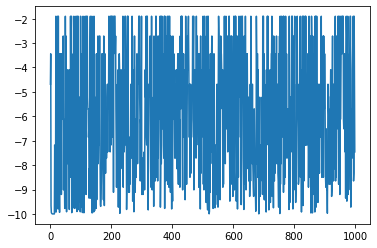

In [6]:
plt.plot(rewards)